In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere

import xgboost

# procesamiento
import pandas as pd
import numpy as np
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere

# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [3]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932


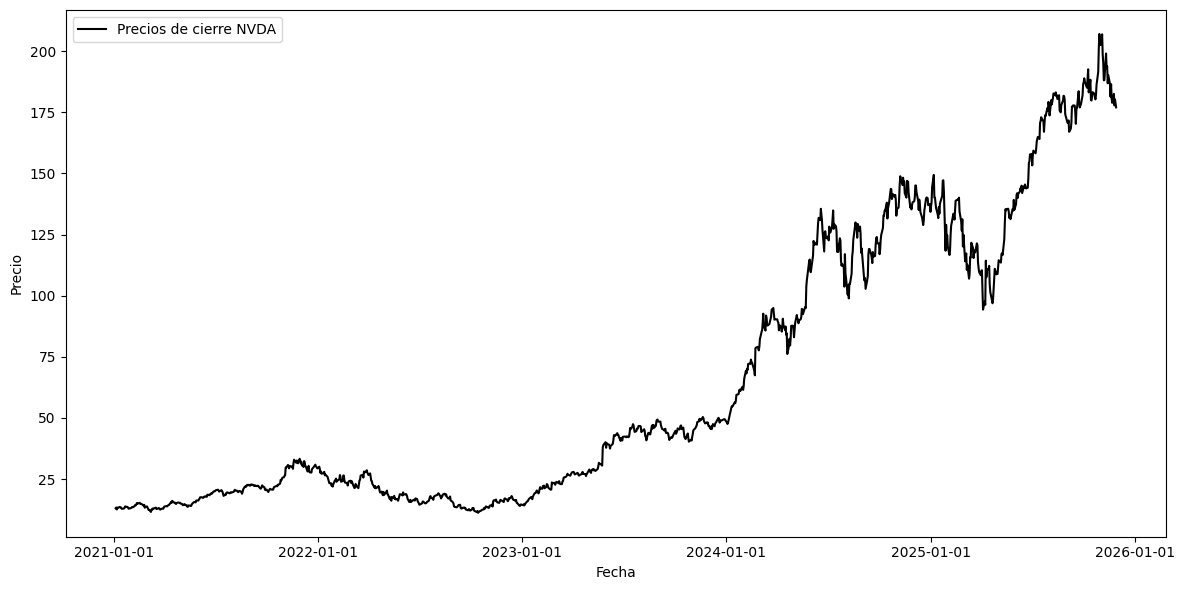

In [5]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA", color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [ ]:
""" # se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
percentage = 0.9 # porcentaje de datos para folds
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final """

In [ ]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
#forecast_size = 20 # porcentaje de datos para folds
percentage = 0.9
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
#val_start_date = folds_data["Date"][-1:].values[0]
val_start_date = val_data["Date"].iloc[0]

#val_start_date["Date"] 

val_data.tail()

In [ ]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["Date"], folds_data["NVDA"], label="data folds")
plt.plot(val_data["Date"], val_data["NVDA"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [ ]:
#folds_data["NVDA_log"] = np.log(folds_data["NVDA"])

In [ ]:
""" # función para identificar los datos del dataframe en formato supervisado, es decir, deon se tengan las etiquetas datos requeridos/respuesta
def make_supervised(df, target_col, lags=1, exog_cols=None):
    df_super = df.copy()
    
    # Lista de columnas a eliminar (target + exógenas originales + otras)
    cols_to_drop = [target_col]
    if exog_cols:
        cols_to_drop.extend(exog_cols)
    if "Date" in df_super.columns:
        cols_to_drop.append("Date")
        
    # --- 1. Crear retardos del target (Comienza en lag 1) ---
    for lag in range(1, lags + 1):
        df_super[f"{target_col}_lag_{lag}"] = df_super[target_col].shift(lag)
        
    # --- 2. Crear retardos de variables exógenas (Comienza en lag 1 para evitar leakage) ---
    if exog_cols:
        for col in exog_cols:
            # CORRECCIÓN CLAVE: El lag empieza en 1, NO en 0
            for lag in range(1, lags + 1): 
                df_super[f"{col}_lag_{lag}"] = df_super[col].shift(lag)
                
    # 3. Eliminar filas con NaN (debido a los shifts)
    df_super = df_super.dropna()
    
    # 4. Asignar X (features) y y (target)
    # CORRECCIÓN: Usa la lista 'cols_to_drop' para eliminar las columnas originales, NO los lags
    X = df_super.drop(columns=cols_to_drop)
    y = df_super[target_col]
    
    # Retorna X (features), y (target) y df_super (dataframe supervisado)
    return X, y, df_super """

In [ ]:
def make_supervised(df, target_col, lags=1, exog_cols=None):
    df_super = df.copy()

    # columnas a quitar para generar X
    cols_to_drop = [target_col]
    if exog_cols:
        cols_to_drop.extend(exog_cols)
    if "Date" in df_super.columns:
        cols_to_drop.append("Date")

    # generar lags del target
    for lag in range(1, lags + 1):
        df_super[f"{target_col}_lag_{lag}"] = df_super[target_col].shift(lag)

    # generar lags de exógenas
    if exog_cols:
        for col in exog_cols:
            for lag in range(1, lags + 1):
                df_super[f"{col}_lag_{lag}"] = df_super[col].shift(lag)

    # eliminar las filas con NaN (lags)
    df_super = df_super.dropna()

    # features y target
    X = df_super.drop(columns=cols_to_drop)
    y = df_super[target_col]

    return X, y, df_super


In [ ]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = len(val_data)
gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
n_splits = 8
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=size_test, gap=gap)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

In [ ]:
""" # visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
#size_test = int(len(val_data) * 0.4)
size_test = int(len(folds_data) * 0.05)

gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
#tscv = TimeSeriesSplit(n_splits=6, test_size=size_test, gap=gap)
tscv = TimeSeriesSplit(
    n_splits=9,
    test_size=size_test,
    gap=0
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show() """

In [ ]:
# función de creación del modelo 
def build_xgboost_regressor(**params):
    # puedes establecer valores por defecto si faltan
    params.setdefault("objective", "reg:squarederror")
    params.setdefault("tree_method", "hist")
    params.setdefault("random_state", 42)

    model = xgboost.XGBRegressor(**params)
    return model

        


# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [ ]:
def objective(trial):
    # Parámetros del modelo
    lag = trial.suggest_categorical("lag", [1, 7, 15, 30, 90])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 15.0),
        "gamma": trial.suggest_float("gamma", 1e-3, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 5.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective": "reg:squarederror",
        "tree_method": "exact",
        "random_state": 42
    }

    # Datos supervisados
    X_full, y_full, _ = make_supervised(
        folds_data,
        target_col="NVDA",
        lags=lag,
        exog_cols=["SPX"]
    )


    # Métricas a recolectar
    mapes, maes, rmses, smapes = [], [], [], []



    # Validación cruzada temporal
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
        np.random.seed(42)

        # División train/test (sin escalado)
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train = y_full.iloc[train_idx].values
        y_test  = y_full.iloc[test_idx].values

        
        # Entrenamiento, prediccion y metricas 
        model = build_xgboost_regressor(**params)
        model.fit(X_train, y_train)


        y_pred = model.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True) 
        smape = smape_calc(y_test, y_pred)

        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        # Registro 
        trial.set_user_attr(f"fold_{fold_idx + 1}", {
            "mae": mae,
            "mape": mape,
            "rmse": rmse, 
            "smape": smape
        })
        trial.report(np.mean(mapes), step=fold_idx)

   
    # Función objetivo
    mean_mape = np.mean(mapes)
    trial.set_user_attr("mape_mean", mean_mape)
    
    std_mape  = np.std(mapes)
    return float(mean_mape) #+ 0.25 * std_mape)


In [ ]:
print("Optimización con Optuna en curso...")
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50)
best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)


In [ ]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)


In [ ]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    #print(attrs)

In [ ]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": int(key.replace("fold_", "")),   # extraer número
                "mape": value["mape"],
                "mae": value["mae"],
                "rmse": value["rmse"],
                "smape": value["smape"]
            })

df_metrics = pd.DataFrame(rows)
df_metrics.head()

In [ ]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

In [ ]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax)
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Ordenar por cada métrica
df_mape_sorted = df_metrics.sort_values("mape").reset_index(drop=True)
df_mae_sorted = df_metrics.sort_values("mae").reset_index(drop=True)
df_rmse_sorted = df_metrics.sort_values("rmse").reset_index(drop=True)

print("Peores Folds por MAPE:")
print(df_mape_sorted.tail())

print("\nPeores Folds por MAE:")
print(df_mae_sorted.tail())

print("\nPeores Folds por RMSE:")
print(df_rmse_sorted.tail())

print("\nPeores Folds por sMAPE:")
print(df_rmse_sorted.tail())

In [ ]:

# Corrección
params_xgb = {
    k: v 
    for k, v in study.best_params.items() 
    if k != 'lag'
}
study.best_params

# La variable params_xgb contendrá solo los hiperparámetros de XGBoost
# (n_estimators, max_depth, learning_rate, etc.), excluyendo 'lag'.

In [ ]:
""" X_val, y_val, _ = make_supervised(
    val_data, 
    target_col="NVDA", 
    lags=study.best_params["lag"],
    exog_cols=["SPX"]
) """

In [ ]:
""" X_init, y_init, _ = make_supervised(
    folds_data, 
    target_col="NVDA", 
    lags=study.best_params["lag"],  
    exog_cols=["SPX"]
) """

In [ ]:
# Datos supervisados solo con los folds
X_train_oos, y_train_oos, df_train_super = make_supervised(
    folds_data,
    target_col="NVDA",
    lags=study.best_params["lag"],
    exog_cols=["SPX"]
)

# Datos supervisados solo con el OOS
X_test_oos, y_test_oos, df_test_super = make_supervised(
    val_data,
    target_col="NVDA",
    lags=study.best_params["lag"],
    exog_cols=["SPX"]
)


In [ ]:
model = build_xgboost_regressor(**params_xgb)

# número de iteraciones en las que se fija el modelo
lista_errores = []
iters = 1

for i in range(iters):
    model.fit(X_train_oos, y_train_oos)
    forecasts = model.predict(X_test_oos)
    """ forecast_rescaled = scaler_y.inverse_transform(
            np.hstack([forecasts.reshape(-1,1), np.zeros((len(forecasts), len(X_val_copy.columns) - 1))])
        )[:, 0] """
        # de nuevo, la transformación de las variables se hizo en conjunto, por lo que 
        # hay dos columnas en los datos de validación. 
        # para usar el escalado inverso, se requiere que los datos a usar tengan las mismas
        # dimensiones que los datos originales. Por lo que a la columna de predicciones
        # se le añade una "columna" con ceros antes de reescalar y luego se toma solo la 
        # primera columna
    
    # ahora se evaluan los errores
    y_true = val_data["NVDA"].values
    #medians_df['predictions'] = float(list(forecasts))
    mape_iter = mean_absolute_percentage_error(y_test_oos, forecasts)
    #mape_iter = mean_absolute_percentage_error(y_true[-len(forecasts):], forecasts)
    #mae_iter = mean_absolute_error(y_true[-len(forecasts):], forecasts)
    mae_iter = mean_absolute_error(y_test_oos, forecasts)
    #rmse_iter = float(np.sqrt(mean_squared_error(y_true[-len(forecasts):], forecasts)))
    rmse_iter = float(np.sqrt(mean_squared_error(y_test_oos, forecasts)))

    # se añaden los errores y las predicciones dadas por los modelos como registros de 
    # la lista, para graficar y ver errores por iteración
    lista_errores.append({
        "iter": i + 1,
        "mae": mae_iter,
        "mape": mape_iter,
        "rmse": rmse_iter,
        "forecasts": forecasts,
    })

    


In [ ]:
len(forecasts)

In [ ]:
# Cálculo de métricas agregadas

mape_median = np.median([x["mape"] for x in lista_errores])
mae_median  = np.median([x["mae"] for x in lista_errores])
rmse_median = np.median([x["rmse"] for x in lista_errores])

# Convertir las predicciones a lista nativa (para que sea JSON serializable)
predictions_list = np.asarray(lista_errores[-1]["forecasts"]).astype(float).ravel().tolist()

# Crear el DataFrame medians_df
medians_df = pd.DataFrame({
    "mape_median": [mape_median],
    "mae_median": [mae_median],
    "rmse_median": [rmse_median],
    "predictions": [predictions_list]  # lista dentro de una celda
})

# Exportar a JSON sin error
#medians_df.to_json("../data/best_parameters/preds_xgb.json", orient="records")


In [ ]:
predictions_list

In [ ]:
print(model.get_xgb_params())  # confirma que 'gamma' aparece con tu valor

In [ ]:
# se imprimen los errores por iteracion
for el in lista_errores:
    print(f"errores iteracion {el['iter']}: \n")
    print(f"mae iter {el['iter']}: {el['mae']}")
    print(f"mape iter {el['iter']}: {el['mape']}")
    print(f"rmse iter {el['iter']}: {el['rmse']}")

In [ ]:
len(val_data)

In [ ]:
# se grafican los datos de prueba vs los pronosticos dados en cada una de las iters
#112

plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(X_data_test)], df_data_close["NVDA"][:-len(X_data_test)], label="Precio real NVDA - train", color="gray")
#plt.plot(val_data["Date"][-len(val_data):], val_data["NVDA"][-len(val_data):], label="Precio real NVDA", color="black", alpha=1, linewidth=2)
plt.plot(val_data["Date"][-len(predictions_list):], val_data["NVDA"][-len(predictions_list):], label="Precio real NVDA", color="black", alpha=1, linewidth=2)
for i, resultado in enumerate(lista_errores):
    
    #plt.plot(val_data["Date"][-len(forecast_rescaled):], forecast_rescaled, label=f"Precio pronosticado XGBoost - intento {i+1}", alpha=1, color='orange')
    plt.plot(val_data["Date"][-len(predictions_list):], predictions_list, label=f"Precio pronosticado XGBoost - intento {i+1}", alpha=1, color='orange')
#plt.plot(val_data["Date"][-len(predictions_rescaled):], predictions_rescaled, label="Precio pronosticado RNN", color="orange")
#plt.plot(train_data["Date"], train_data["NVDA"], label="train", color="gray")
#plt.plot(test_data["Date"], test_data["NVDA"], label="test", color="orange")
#plt.axvline(fecha_corte, color="black", linestyle="-")
plt.title("Predicción de precios NVDA usando XGBoost con variables exógenas (SP500, VIX)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

In [ ]:
# se toman los valores promedio de cada una de las medidas
list_mapes, list_maes, list_rmses = [], [], []
for el in lista_errores:
    list_mapes.append(el["mape"])
    list_maes.append(el["mae"])
    list_rmses.append(el["rmse"])
print(f"mape prom validacion: {np.mean(list_mapes)}")
print(f"mae prom validacion: {np.mean(list_maes)}")
print(f"rmse prom validacion: {np.mean(list_rmses)}")